# Variable/Constants & Imports

In [1]:
import numpy as np
from collections.abc import Callable
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL, ExtendedUnbinnedNLL, LeastSquares
from scipy.stats import expon, norm, uniform, chi2
from scipy.integrate import quad
import plotly.graph_objects as go
from library import dataset_analysis, end, dataset_analysis_unbinned
n_bins = 57

N = 9874
TAU_MU = 2.1969811e-6
exp_args = {"a": 1, "A": 0, "tau": TAU_MU}

# Functions

## Utilities

In [2]:
def sturges( N: int):
    return int(np.round( 1 + np.log2(N)))


def dataset_splitter(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    data = data.T
    discriminator = np.array([bool(i) for i in data[1]])


    data_g = data[0][discriminator]
    data_p = data[0][~discriminator]
    return data_g, data_p


def find_best_chi2_pvalue( min_bin_range:int , max_bin_range:int , step_bin: int,  f:Callable , dataset:np.ndarray , f_args:dict):
    range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)

    p_value_list = []
    chi2_list = []
    for bin in range_bins:
        n = dataset_analysis( dataset , f , bins = bin , args=f_args)
        n.migrad()
        n.hesse()
        p_value_list.append(1 - chi2.cdf(n.fval, df=n.ndof))
        if n.fval == None:
            raise KeyError(f"finterpolation failed at bin: {bin}")
        chi2_list.append(n.fval/n.ndof)
    return p_value_list , chi2_list

## Models

### CDFs

In [3]:
def exp( x , N ,a, A, tau):
    return a*N*expon.cdf(x , A , tau) 

def exp_unif(x, N , min , max , a, b, tau, A):
    return a * N * expon.cdf(x, A, tau) + b * N * uniform.cdf(x, min, max)

def exp_unif_renorm(x, N , min , max , a, b, tau, A):
    return a * N * (expon.cdf(x, A, tau)*tau/(expon.cdf(max , loc = A , scale = tau) - expon.cdf(min , loc = A , scale = tau))) + b * N * uniform.cdf(x, min, max)

def double_exp( x , N , a , b , tau1 , tau2 , A ):
    return a * N * (expon.cdf(x, A, tau1)) + b * N * (expon.cdf(x, A, tau2))

def double_exp_unif( x , N , min , max,  a , b , c , tau1 , tau2 , A ):
    return a * N * (expon.cdf(x, A, tau1)) + b * N * (expon.cdf(x, A, tau2)) + c * N * (uniform.cdf(x, min, max))



### PDFs

In [4]:
def exp_pdf( x , a, A, tau):
    return a * expon.pdf(x , A , tau) 

def exp_unif_pdf(x, a, b, tau, A , e):
    return a * (expon.pdf(x, A, tau) + b * uniform.pdf(x, 0, e))

def exp_unif_renorm_pdf(x, min , max , a, b, tau, A):
    return a * (expon.pdf(x, A, tau)*tau/(expon.cdf(max , loc = A , scale = tau) - expon.cdf(min , loc = A , scale = tau))) + b * uniform.pdf(x, min, max)

def double_exp_pdf( x , a , b , tau1 , tau2 , A ):
    return a * (expon.pdf(x, A, tau1)) + b * (expon.pdf(x, A, tau2))

def double_exp_unif_pdf( x , a , b , c , tau1 , tau2 , A , e):
    return a * (expon.pdf(x, A, tau1)) + b * (expon.pdf(x, A, tau2)) + c * (uniform.pdf(x, 0, e))


# Dataset

In [5]:
data_0 = np.genfromtxt("Data/timestamp/21_01_2024_17_42.csv", delimiter=',')
data_1 = np.genfromtxt("Data/timestamp/23_01_2026_17_31.csv", delimiter=',')
data_2 = np.genfromtxt("Data/timestamp/29_01_2026_17_20.csv", delimiter=',')
data_3 = np.genfromtxt("Data/timestamp/02_02_2026_17_14.csv", delimiter=',')
data_4 = np.genfromtxt("Data/timestamp/05_02_2026_18_17.csv", delimiter=',')
data_5 = np.genfromtxt("Data/timestamp/11_02_2026_17_52.csv", delimiter=',')
data_6 = np.genfromtxt("Data/timestamp/16_02_2026_12_25.csv", delimiter=',')
data_7 = np.genfromtxt("Data/timestamp/20_02_2026_15_57.csv", delimiter=',')
inv_data_1 = np.genfromtxt("Data/timestamp/inverted_26_02_2026_16_57.csv" , delimiter=',')
mult_data_1 = np.genfromtxt("Data/timestamp/triple_04_03_2026_05_12.csv",delimiter=",")
mult_data_2 = np.genfromtxt("Data/timestamp/triple_06_03_2026_14_12.csv" , delimiter=",")

data_g_1 , data_p_1 = dataset_splitter( mult_data_1)
data_g_2 , data_p_2 = dataset_splitter( mult_data_2)
print( np.shape(data_g_2) , np.shape(data_g_1))
data_g = np.concatenate((data_g_1, data_g_2))
data_p = np.concatenate( (data_p_1 , data_p_2))




data = np.concatenate((data_0, data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_g, data_p , inv_data_1))

print(len(data),len(data_0), len(data_1), len(data_2), len(data_3), len(data_4), len(data_5), len(data_6), len(data_7) , len(inv_data_1))


(5798,) (1050,)
74327 2976 9400 6139 4577 8759 7456 6355 4137 9874


## Hists

In [6]:

# data_2 = data_2[(data_2 > 0.6e-6) & (data_2 < 1.8e-6)]
inv_data_1_cut = inv_data_1[(inv_data_1 > 3e-7)&(inv_data_1 < 7.6e-6)]
count, edges = np.histogram(data, bins=n_bins , density=False)
count_1, edges_1 = np.histogram(data_1, bins=n_bins , density=False)
count_2, edges_2 = np.histogram(data_2, bins=n_bins , density=False)
count_3, edges_3 = np.histogram(data_3, bins=n_bins , density=False)
count_4, edges_4 = np.histogram(data_4, bins=n_bins , density=False)
count_5, edges_5 = np.histogram(data_5, bins=n_bins , density=False)
count_6, edges_6 = np.histogram(data_6, bins=n_bins , density=False)
count_7, edges_7 = np.histogram(data_7, bins=n_bins , density=False)
count_8, edges_8 = np.histogram(inv_data_1_cut, bins=n_bins , density=False)
print (len(data), len(data_1))
fig = go.Figure()

fig.add_trace(go.Bar(x=edges[:-1],  y=count   / len(data),   name='total',        width=np.diff(edges)))
fig.add_trace(go.Bar(x=edges_1[:-1], y=count_1 / len(data_1), name='23/01/2026',   width=np.diff(edges_1)))
fig.add_trace(go.Bar(x=edges_2[:-1], y=count_2 / len(data_2), name='29/01/2026',   width=np.diff(edges_2)))
fig.add_trace(go.Bar(x=edges_3[:-1], y=count_3 / len(data_3), name='02/02/2026',   width=np.diff(edges_3)))
fig.add_trace(go.Bar(x=edges_4[:-1], y=count_4 / len(data_4), name='05/02/2026',   width=np.diff(edges_4)))
fig.add_trace(go.Bar(x=edges_5[:-1], y=count_5 / len(data_5), name='11/02/2026',   width=np.diff(edges_5)))
fig.add_trace(go.Bar(x=edges_6[:-1], y=count_6 / len(data_6), name='16/02/2026',   width=np.diff(edges_6)))
fig.add_trace(go.Bar(x=edges_7[:-1], y=count_7 / len(data_7), name='20/02/2026',   width=np.diff(edges_7)))
fig.add_trace(go.Bar(x=edges_8[:-1], y=count_8 / len(inv_data_1_cut), name='inverted_26_02_2026_16_57',   width=np.diff(edges_7)))
fig.update_layout(
    xaxis_title='Time (s)',
    yaxis_title='Counts',
    bargap=0
)

fig.show()

74327 9400


# Analysis First set

## Full interpolation 

E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.
E VariableMetricBuilder Initial matrix not pos.def.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 49.44 (χ²/ndof = 0.8)      │              Nfcn = 364              │
│ EDM = 2.49e-06 (Goal: 0.0002)    │            time = 0.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   436e3   │    4e3    │    -4e3    │    4e3     │         │         │       │
│ 1 │ b    │   0.080   │   0.017   │   -0.017   │   0.016    │         │         │       │
│ 2 │ tau  │  2.13e-6  │  0.04e-6  │  -0.04e-6  │  0.04e-6   │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -4e3    │    4e3    │  -0.017   │   0.016   │ -0.04e-6  │  0.04e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────────┐
│     │                  a                  b                tau                  A │
├─────┼─────────────────────────────────────────────────────────────────────────────┤
│   a │           1.63e+07           24.87225 -110.6692229262e-6                  0 │
│   b │           24.87225           0.000273      -676.0836e-12                  0 │
│ tau │ -110.6692229262e-6      -676.0836e-12           1.92e-15                  0 │
│   A │                  0                  0                  0                  0 │
└─────┴─────────────────────────────────────────────────────────────────────────────┘

(array([2.04135105e-06, 2.04739685e-06, 2.05344264e-06, 2.05948844e-06,
        2.06553423e-06, 2.07158003e-06, 2.07762582e-06, 2.08367162e-06,
        2.08971741e-06, 2.09576321e-06, 2.10180900e-06, 2.10785480e-06,
        2.11390059e-06, 2.11994639e-06, 2.12599218e-06, 2.13203798e-06,
        2.13808377e-06, 2.14412957e-06, 2.15017536e-06, 2.15622116e-06,
        2.16226695e-06, 2.16831275e-06, 2.17435854e-06, 2.18040433e-06,
        2.18645013e-06, 2.19249592e-06, 2.19854172e-06, 2.20458751e-06,
        2.21063331e-06, 2.21667910e-06]),
 array([4.29735054e+00, 3.70578228e+00, 3.16059013e+00, 2.66121848e+00,
        2.20665673e+00, 1.79659987e+00, 1.43044866e+00, 1.10715776e+00,
        8.26394413e-01, 5.87520070e-01, 3.89913085e-01, 2.32965762e-01,
        1.16082131e-01, 3.87796648e-02, 1.72684009e-04, 0.00000000e+00,
        3.76973608e-02, 1.12414964e-01, 2.23905613e-01, 3.71532381e-01,
        5.54766356e-01, 7.73087198e-01, 1.02598345e+00, 1.31295281e+00,
        1.63350236e+00

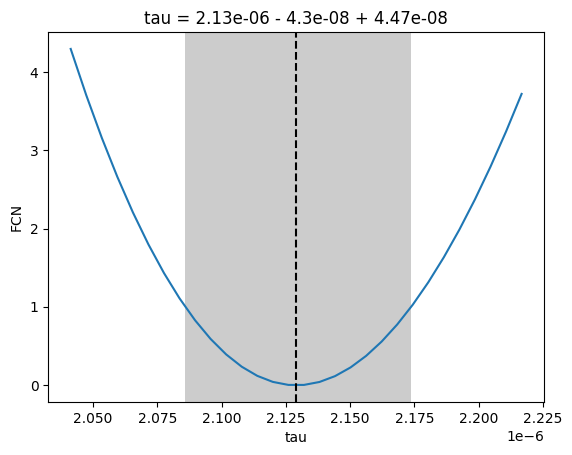

In [ ]:
n_bins = 67


data_refact:np.ndarray = data[(data > 7e-7)&(data < 6.5e-6)]## forse si può anche non tagliare dal basso


# n = dataset_analysis( data_refact , exp , bins = n_bins , args= {"a": 1, "A": 0, "tau": TAU_MU})
# end(n)



full_analysis = dataset_analysis( data_refact , exp_unif_renorm , bins = n_bins , args={"a": 0.9, "b":0.1,"tau": TAU_MU , "A":0})
# full_analysis.limits["a" , "b"] = (0,1) #type:ignore
# m.fixed["e"] = True
end(full_analysis , False)

full_analysis.draw_mnprofile("tau")




In [8]:
print(len(data_2),'\n', 'rate di decadimenti muonici tra il 29genn-2febbr:', 1/(len(data_2)/((24*4)*3600)), 'Hz')
print (len(data_3),'\n', 'rate di decadimenti muonici tra il 2-5 febbraio:', 1/(len(data_3)/((24*3+1)*3600)), 'Hz')
print (len(data_4),'\n', 'rate di decadimenti muonici tra il 5-11 febbraio:', 1/(len(data_4)/((24*4+20)*3600)), 'Hz')

6139 
 rate di decadimenti muonici tra il 29genn-2febbr: 56.29581365043167 Hz
4577 
 rate di decadimenti muonici tra il 2-5 febbraio: 57.4175223945816 Hz
8759 
 rate di decadimenti muonici tra il 5-11 febbraio: 47.67667541956844 Hz


## Plot result + Discrepancy analysis

In [9]:
count,edges = np.histogram(data_refact , n_bins)


fig = go.Figure()
fig.add_trace(go.Bar(x=edges[:-1], y=count/len(data_refact), name='total', width=np.diff(edges)))

x_fit = np.linspace(min(data_refact) , max(data_refact) , n_bins)
y_fit = exp_unif_renorm_pdf( x_fit , min(data_refact) , max(data_refact), *full_analysis.values)*np.diff( edges )[0]
y_ideal_fit = exp_unif_renorm_pdf(x_fit , min(data_refact) , max(data_refact), full_analysis.values["a"], full_analysis.values["b"], TAU_MU , 0)*np.diff(edges)[0]
fig.add_trace(go.Scatter(x=x_fit, y=y_fit, mode='lines', name='fit', line=dict(shape='linear')))
fig.add_trace(go.Scatter(x=x_fit, y=y_ideal_fit, mode='lines', name='ideal fit', line=dict(shape='linear')))

In [10]:
# ho provato a vedere come fossero gli errori poissoniani usando i risultati dell'interpolazione come base

res = (count/len(data_refact)) - y_fit
res_ideal = count/len(data_refact) - y_ideal_fit

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_fit, y=res, mode='markers',  name='residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal, mode='markers',  name='ideal residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res/count * len(data_refact), mode='markers',  name='relative residuals'))
fig.add_trace(go.Scatter(x=x_fit, y=res_ideal/count * len(data_refact), mode='markers',  name='relative ideal residuals'))

fig.show()

In [11]:
min_bin_range = 3
max_bin_range = 200
step_bin = 1
p_value_list , chi2_list = find_best_chi2_pvalue(min_bin_range , max_bin_range ,step_bin , exp , data_refact , exp_args)



In [12]:
fig = go.Figure()

range_bins = np.arange(min_bin_range , max_bin_range , step_bin , dtype=int)

fig.add_trace( go.Scatter( x = range_bins , y = p_value_list , mode="markers" , name="p_value"))
fig.add_trace( go.Scatter( x = range_bins , y = chi2_list , mode="markers" , name="chi squared"))
fig.add_vline(x= sturges(len(data_refact)), line_dash="dash", line_color="purple" , name= "sturges value for binning")
fig.add_hline( y= max(p_value_list) , line_dash="dash", line_color="green" , name= "minimum p_value")
fig.update_layout(showlegend=True)
fig.show()



## Plot  Least Squares

In [13]:
data_refact:np.ndarray = data[(data>1e-7)&(data<7e-6)]

count_LS , edges_LS = np.histogram( data_refact , bins=n_bins)

edges_LS = [ (edges_LS[i+1] + edges_LS[i])/2 for i in range(len(count_LS))]

# fig = go.Figure()
# fig.add_trace( go.Scatter( x = edges_LS , y = count_LS, mode="lines" , name="p_value"))
# fig.show()


ls = LeastSquares( edges_LS , count_LS , np.sqrt(count_LS) , exp_unif_pdf)
exp_unif_args = {"a": 0.9, "N": len(data_refact),"b": 0, "tau": TAU_MU , "A":0 , "e": max(data_refact)}
minuit = Minuit( ls , 0.9 , 0 , TAU_MU , 0 , max(data_refact))
minuit.fixed["A"] = True
minuit.migrad()
minuit.hesse()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 153.3 (χ²/ndof = 2.4)      │              Nfcn = 522              │
│ EDM = 4.28e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │ 7.832e-3  │ 0.030e-3  │            │            │         │         │       │
│ 1 │ b    │   11.3    │    2.0    │            │            │         │         │       │
│ 2 │ tau  │ 2.312e-6  │ 0.013e-6  │            │            │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 4 │ e    │    5.5    │    2.0    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────────────────────────────────────────────────┐
│     │             a             b           tau             A             e │
├─────┼───────────────────────────────────────────────────────────────────────┤
│   a │      9.12e-10      -48.6e-9     63.28e-15             0       98.8e-9 │
│   b │      -48.6e-9          3.99 -16.67294e-12             0            -0 │
│ tau │     63.28e-15 -16.67294e-12      1.64e-16             0  33.91938e-12 │
│   A │             0             0             0             0             0 │
│   e │       98.8e-9            -0  33.91938e-12             0             4 │
└─────┴───────────────────────────────────────────────────────────────────────┘

## Double Exponential Interpolation

In [14]:
data_refact:np.ndarray = data[(data>1e-7)&(data<7e-6)]

double_exp_args = {"a": 0.9, "b": 0.2,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0 }
double = dataset_analysis( data_refact , double_exp , bins = n_bins , args=double_exp_args)
# double.limits["a" , "b"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 108 (χ²/ndof = 1.7)        │              Nfcn = 885              │
│ EDM = 4.27e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.00    │   0.09    │   -0.09    │    0.09    │         │         │       │
│ 1 │ b    │   0.25    │   0.32    │   -0.32    │    0.32    │         │         │       │
│ 2 │ tau1 │  2.09e-6  │  0.10e-6  │  -0.10e-6  │  0.10e-6   │         │         │       │
│ 3 │ tau2 │  0.02e-3  │  0.04e-3  │  -0.04e-3  │  0.04e-3   │         │         │       │
│ 4 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │         tau1          │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.09   │   0.09    │   -0.32   │   0.32    │  -0.1e-6  │  0.1e-6   │ -0.04e-3  │  0.04e-3  │
│  Valid   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬──────────────────────────────────────────────────────────────────┐
│      │            a            b         tau1         tau2            A │
├──────┼──────────────────────────────────────────────────────────────────┤
│    a │      0.00742        0.027  8.274127e-9    3.6629e-6        0.000 │
│    b │        0.027        0.102 28.521303e-9   13.6947e-6          0.0 │
│ tau1 │  8.274127e-9 28.521303e-9     9.58e-15    3.998e-12        0e-15 │
│ tau2 │    3.6629e-6   13.6947e-6    3.998e-12     1.86e-09            0 │
│    A │        0.000          0.0        0e-15            0            0 │
└──────┴──────────────────────────────────────────────────────────────────┘

# Analysis inversed Dataset

## Single Exponential interpolation

In [15]:
data_refact = inv_data_1[(inv_data_1 > 3e-7)&(inv_data_1 < 7.6e-6)]

exp_unif_args = {"a": 0.9,"b": 0.1, "tau": TAU_MU , "A":0}
full_analysis = dataset_analysis( data_refact , exp_unif , bins = n_bins , args=exp_unif_args)
end(full_analysis)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 60.33 (χ²/ndof = 0.9)      │              Nfcn = 260              │
│ EDM = 3.45e-07 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.137   │   0.030   │   -0.030   │   0.031    │         │         │       │
│ 1 │ b    │   0.051   │   0.025   │   -0.025   │   0.024    │         │         │       │
│ 2 │ tau  │  2.11e-6  │  0.08e-6  │  -0.08e-6  │  0.08e-6   │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.030   │   0.031   │  -0.025   │   0.024   │ -0.08e-6  │  0.08e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │            a            b          tau            A │
├─────┼─────────────────────────────────────────────────────┤
│   a │      0.00093      -0.7e-3  1.938455e-9            0 │
│   b │      -0.7e-3     0.000624 -1.759238e-9            0 │
│ tau │  1.938455e-9 -1.759238e-9      6.1e-15        0e-15 │
│   A │            0            0        0e-15            0 │
└─────┴─────────────────────────────────────────────────────┘

## Double exponential interpolation

In [16]:
data_refact = inv_data_1[(inv_data_1 > 5e-7)&(inv_data_1 < 7.6e-6)]

double_exp_unif_args = {"a": 0.9, "b": 0.2, "c":0.0,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0}
double = dataset_analysis( data_refact , double_exp_unif , bins = n_bins , args=double_exp_unif_args)
double.fixed["c"] = True
double.limits["a" , "b" , "c"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 44.91 (χ²/ndof = 0.7)      │             Nfcn = 1586              │
│ EDM = 1.18e-05 (Goal: 0.0002)    │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.11    │   0.05    │   -0.05    │    0.13    │    0    │    2    │       │
│ 1 │ b    │   1.24    │   0.06    │   -0.13    │    0.04    │    0    │    2    │       │
│ 2 │ c    │    0.0    │    0.1    │            │            │    0    │    2    │  yes  │
│ 3 │ tau1 │  0.62e-6  │  0.37e-6  │  -0.31e-6  │  0.52e-6   │         │         │       │
│ 4 │ tau2 │  2.42e-6  │  0.11e-6  │  -0.09e-6  │  0.18e-6   │         │         │       │
│ 5 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │         tau1          │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.13    │   -0.13   │   0.04    │ -0.31e-6  │  0.52e-6  │ -0.09e-6  │  0.18e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬───────────────────────────────────────────────────────────────────────────────┐
│      │            a            b            c         tau1         tau2            A │
├──────┼───────────────────────────────────────────────────────────────────────────────┤
│    a │      0.00304      -0.0030        0.000  13.41262e-9  5.261823e-9        0.000 │
│    b │      -0.0030      0.00371        0.000 -19.74682e-9 -5.829546e-9        0.000 │
│    c │        0.000        0.000            0            0            0            0 │
│ tau1 │  13.41262e-9 -19.74682e-9            0     1.35e-13    0.030e-12            0 │
│ tau2 │  5.261823e-9 -5.829546e-9            0    0.030e-12     1.17e-14            0 │
│    A │        0.000        0.000            0            0            0            0 │
└──────┴───────────────────────────────────────────────────────────────────────────────┘

In [17]:
data_refact = inv_data_1[(inv_data_1 > 5e-7)&(inv_data_1 < 7.6e-6)]

double_exp_args = {"a": 0.9, "b": 0.2,  "tau1": TAU_MU , "tau2": TAU_MU,  "A":0 }
double = dataset_analysis( data_refact , double_exp , bins = n_bins , args=double_exp_args)
double.limits["a" , "b"] = (0 , 2)
end(double)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 44.91 (χ²/ndof = 0.7)      │             Nfcn = 1586              │
│ EDM = 1.18e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.11    │   0.05    │   -0.05    │    0.13    │    0    │    2    │       │
│ 1 │ b    │   1.24    │   0.06    │   -0.13    │    0.04    │    0    │    2    │       │
│ 2 │ tau1 │  0.62e-6  │  0.37e-6  │  -0.31e-6  │  0.52e-6   │         │         │       │
│ 3 │ tau2 │  2.42e-6  │  0.11e-6  │  -0.09e-6  │  0.18e-6   │         │         │       │
│ 4 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │         tau1          │         tau2          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.13    │   -0.13   │   0.04    │ -0.31e-6  │  0.52e-6  │ -0.09e-6  │  0.18e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬──────────────────────────────────────────────────────────────────┐
│      │            a            b         tau1         tau2            A │
├──────┼──────────────────────────────────────────────────────────────────┤
│    a │      0.00304      -0.0030  13.41262e-9  5.261823e-9        0.000 │
│    b │      -0.0030      0.00371 -19.74682e-9 -5.829546e-9        0.000 │
│ tau1 │  13.41262e-9 -19.74682e-9     1.35e-13    0.030e-12            0 │
│ tau2 │  5.261823e-9 -5.829546e-9    0.030e-12     1.17e-14            0 │
│    A │        0.000        0.000            0            0            0 │
└──────┴──────────────────────────────────────────────────────────────────┘

# Analysis multichannel dataset

In [18]:
data_g_refact = data_g[data_g>5e-7]
data_p_refact = data_p[data_p>5e-7]
print(len(data_g) , len(data_p))
exp_unif_args = {"a": 0.9, "b": 0.1,  "tau": TAU_MU , "A":0}
full_analysis = dataset_analysis( data_g_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# g.fixed["e"] = True
end(full_analysis)

p = dataset_analysis( data_p_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# p.fixed["e"] = True
end(p)




complete = np.append( data_g , data_p)
complete_refact = complete[complete>5e-7]


comp = dataset_analysis( complete_refact , exp_unif , bins = n_bins , args=exp_unif_args)
# m.limits["a" , "b"] = (0,1) #type:ignore
# comp.fixed["e"] = True
end(comp)


6848 7806


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 63.29 (χ²/ndof = 1.0)      │              Nfcn = 272              │
│ EDM = 5e-07 (Goal: 0.0002)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.24    │   0.05    │   -0.05    │    0.06    │         │         │       │
│ 1 │ b    │   0.06    │   0.04    │   -0.05    │    0.04    │         │         │       │
│ 2 │ tau  │  2.38e-6  │  0.14e-6  │  -0.14e-6  │  0.15e-6   │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.06    │   -0.05   │   0.04    │ -0.14e-6  │  0.15e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │            a            b          tau            A │
├─────┼─────────────────────────────────────────────────────┤
│   a │        0.003      -0.0023  6.694656e-9        0.000 │
│   b │      -0.0023      0.00201 -5.870258e-9        0.000 │
│ tau │  6.694656e-9 -5.870258e-9     2.02e-14            0 │
│   A │        0.000        0.000            0            0 │
└─────┴─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 50.81 (χ²/ndof = 0.8)      │              Nfcn = 262              │
│ EDM = 2.96e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.234   │   0.036   │   -0.035   │   0.038    │         │         │       │
│ 1 │ b    │   0.067   │   0.030   │   -0.031   │   0.030    │         │         │       │
│ 2 │ tau  │  2.17e-6  │  0.09e-6  │  -0.09e-6  │  0.10e-6   │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.038   │  -0.031   │   0.030   │ -0.09e-6  │  0.10e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │            a            b          tau            A │
├─────┼─────────────────────────────────────────────────────┤
│   a │      0.00131      -1.0e-3  2.690689e-9       0.0000 │
│   b │      -1.0e-3     0.000929 -2.576127e-9            0 │
│ tau │  2.690689e-9 -2.576127e-9     8.74e-15        0e-15 │
│   A │       0.0000            0        0e-15            0 │
└─────┴─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 56.23 (χ²/ndof = 0.9)      │              Nfcn = 267              │
│ EDM = 1.25e-07 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.236   │   0.030   │   -0.030   │   0.031    │         │         │       │
│ 1 │ b    │   0.061   │   0.025   │   -0.026   │   0.025    │         │         │       │
│ 2 │ tau  │  2.25e-6  │  0.08e-6  │  -0.08e-6  │  0.08e-6   │         │         │       │
│ 3 │ A    │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           a           │           b           │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.030   │   0.031   │  -0.026   │   0.025   │ -0.08e-6  │  0.08e-6  │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │            a            b          tau            A │
├─────┼─────────────────────────────────────────────────────┤
│   a │      0.00093      -0.7e-3  1.984964e-9            0 │
│   b │      -0.7e-3     0.000646 -1.830784e-9            0 │
│ tau │  1.984964e-9 -1.830784e-9     6.24e-15        0e-15 │
│   A │            0            0        0e-15            0 │
└─────┴─────────────────────────────────────────────────────┘

# Hol'up

In [19]:
print(np.mean(data))
print( np.sqrt(np.var(data)))

print( np.sqrt(np.var(data))/ np.sqrt(len(data)))

2.0058682847417496e-06
1.829070209944766e-06
6.70898891650401e-09
